# Assignment 4: Regularization

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
2. How does regularization provide a way of exploring the bias-variance trade-off?
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
4. How do we typically scale variables for use in regularized regression? Why?
5. How is the penalty $\alpha$ typically selected?
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them.
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?

## 1.

1. By adding a penalty to mean squared error that grows in the "size" of the model parameters, we are "charging" the model for each coefficient that the model is using, with larger ones costing more by "boosting" the error with their larger "size". This means that by using more and larger parameters, the model is becoming more complex and may be overfitting, and is therefore more expensive with an error that increases with an increase of parameters. We are therefore making the model remove or reduce the variables with a penalty that are least efficient to improve the model.

2. Regularization provides a way of exploring the bias-variance trade-off because when the coefficeints are closer to 0, the model has a lower variance and will have higher bias as a increases. However, with a lower a, the model will have larger coefficients and therefore lower bias and high variance as it is likely overfitting.

3. While LASSO sends coefficients to 0, or removes them for you, Ridge smoothy shrinks coefficients towards 0 but never removes them. This means that LASSO has more interpretable answers, while Ridge's are more accurate.

4. We typically scale variables for use in a regularized regression by standardizing them. This is because regularization depends on the size of the coefficient, which also depends on the scale of the feature. Therefore, if they are all on the same scale, it allows all of the variables to be measured equally and choose the features that are most important.  

5. The penalty a is typically selected through cross-validation. This means you select a range of a values, and use cross-validation to evaluate the MSE on each. You would then pick the value of a that has the lowst error, which would ideally find the most effective point of the bias-variance trade-off.

6. When conducting cross-validation, you do not include the penalty term. This is because the penalty term is meant to measure the complexity of the model, rather than the accuracy of the model that is estimated in cross-validation. If you used the penalty in cross-validation, it would impact the MSE by favoring a larger a creating a smaller penalty, even if that model is less efficient.

##2.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
#1.

df = pd.read_csv("cars_hw.csv")
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [ ]:
df["Age"] = 2026 - df["Make_Year"]

from sklearn.preprocessing import PolynomialFeatures, StandardScaler

#a.
expander = PolynomialFeatures(degree=3, include_bias=False)
X_poly = expander.fit_transform(df[["Mileage_Run", "Age"]])

#b.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
poly_names = expander.get_feature_names_out()

In [ ]:
#2.

from sklearn.linear_model import LinearRegression

X = X_scaled
y = df["Price"]
model = LinearRegression().fit(X, y)

linear_coefficients = model.coef_

In [ ]:
print(poly_names)

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [ ]:
for name, coef in zip(poly_names, model.coef_):
  print(name, coef)

Mileage_Run 911774.8402226233
Age -248172.18553827342
Mileage_Run^2 -207292.6283285836
Mileage_Run Age -1671212.3563918793
Age^2 350550.7198774649
Mileage_Run^3 -65144.89659917212
Mileage_Run^2 Age 338819.4599153141
Mileage_Run Age^2 716781.5818001862
Age^3 -210037.88763612031


The sign for the interaction between Mileage Run and Age is negative at -1671212.356, indicating that older cars with high mileage have a negative effect on price than their impact alone.

Optimal cost hyperparameter: 88.58667904100822


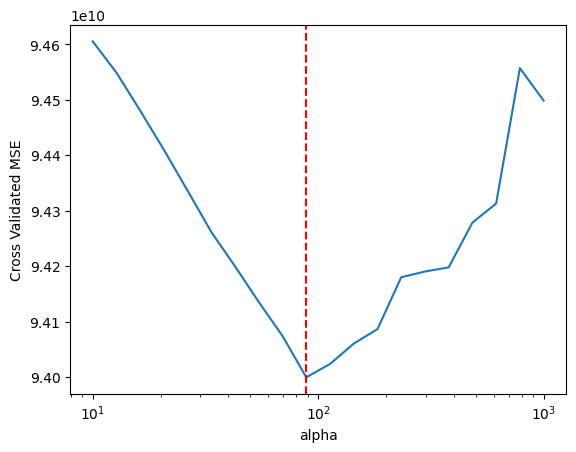

In [ ]:
#3.

from sklearn.linear_model import LassoCV

alphas = np.logspace(1,3,20)
model = LassoCV(cv=20, alphas = alphas, random_state = 100, max_iter = 50000)
model = model.fit(X_scaled, y)

#4.

alpha_star = model.alpha_

sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='red', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

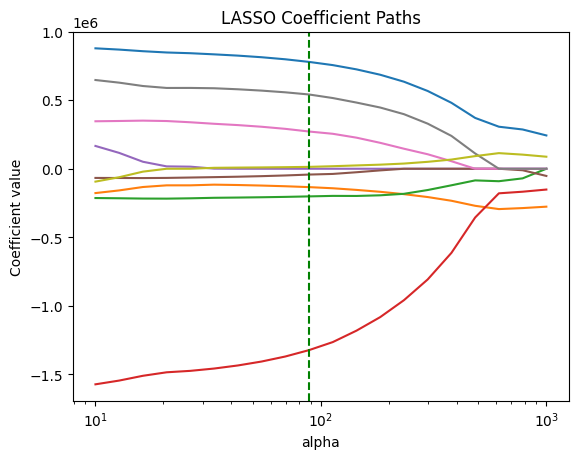

In [ ]:
#5.

from sklearn.linear_model import Lasso

alpha_grid = np.logspace(1, 3, 20)
coefs = []
for alpha in alpha_grid:
    model = Lasso(alpha=alpha, max_iter=100000)
    model = model.fit(X_scaled,y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=poly_names[i])
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

In [ ]:
#6.

selected_features = [name for name, coef in zip(poly_names, model.coef_) if coef != 0]

print("Selected features:", selected_features)

prop_zero_coef = np.sum(model.coef_ == 0)/len(model.coef_)

print("Proportion set equal to zero:", prop_zero_coef)

regularized_coefficients = model.coef_


Selected features: ['Mileage_Run', 'Age', 'Mileage_Run Age', 'Mileage_Run^3', 'Age^3']
Proportion set equal to zero: 0.4444444444444444


In [ ]:
#7.
pd.DataFrame({'Linear regression':linear_coefficients, "Lasso": regularized_coefficients}, index = poly_names)

,Linear regression,Lasso
Mileage_Run,9.117748e+05,242953.216388
Age,-2.481722e+05,-276500.895776
Mileage_Run^2,-2.072926e+05,-0.000000
Mileage_Run Age,-1.671212e+06,-151598.545767
Age^2,3.505507e+05,-0.000000
Mileage_Run^3,-6.514490e+04,-52410.347536
Mileage_Run^2 Age,3.388195e+05,-0.000000
Mileage_Run Age^2,7.167816e+05,-0.000000
Age^3,-2.100379e+05,87796.740706


From linear regression to LASSO, no coefficients decreased, as LASSO shrinks coefficeints to 0 to make the model better with regularization and feature selection. LASSO did reduce some of the coefficeints to 0, including Mileage_Run^2, Age^2, Mileage_Run^2 Age, and Mileage_Run Age^2. It also flipped the sign of the Age^3 coefficeint from negative to positive, likely because of regularization and the correlation of the variables, making the model flip the sign to balance out the correlated features to minimize error.

##3.

In [ ]:
#1.
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [ ]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

expander = PolynomialFeatures(degree=3, include_bias=False)
X_poly = expander.fit_transform(df[["age", "ejection_fraction", "serum_creatinine"]])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
poly_names = expander.get_feature_names_out()

X_Poly2 = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_dummies = X_Poly2.fit_transform(df[["anaemia", "diabetes", "high_blood_pressure", "smoking"]])
dummy_names = X_Poly2.get_feature_names_out()



X_combined = np.concatenate([X_scaled, X_dummies], axis=1)
feature_names = np.concatenate([poly_names, dummy_names])
X_matrix = pd.DataFrame(X_combined, columns=feature_names)
X_matrix.head()

,age,ejection_fraction,serum_creatinine,age^2,age ejection_fraction,age serum_creatinine,ejection_fraction^2,ejection_fraction serum_creatinine,serum_creatinine^2,age^3,...,anaemia,diabetes,high_blood_pressure,smoking,anaemia diabetes,anaemia high_blood_pressure,anaemia smoking,diabetes high_blood_pressure,diabetes smoking,high_blood_pressure smoking
0,1.192945,-1.530560,0.490057,1.177180,-0.939354,0.777328,-1.197120,-0.287340,0.073541,1.124026,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,-0.491279,-0.007077,-0.284552,-0.539187,-0.267742,-0.365953,-0.146835,-0.214284,-0.220393,-0.562311,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.350833,-1.530560,-0.090900,0.252982,-1.167019,-0.031334,-1.197120,-0.518041,-0.161606,0.152154,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.912335,-1.530560,0.490057,-0.885761,-1.508517,0.115061,-1.197120,-0.287340,0.073541,-0.835393,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.350833,-1.530560,1.264666,0.252982,-1.167019,1.237428,-1.197120,0.020262,0.524239,0.152154,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#2.
from sklearn.linear_model import LinearRegression

X = X_matrix
y = df["DEATH_EVENT"]
model = LinearRegression().fit(X, y)

for name, coef in zip(feature_names, model.coef_):
  print(name, coef)

linear_coefficients = model.coef_

age 1.53915560936169
ejection_fraction -2.1924936642342754
serum_creatinine -0.8535881544613186
age^2 -3.6786539253257837
age ejection_fraction -0.6009180269804593
age serum_creatinine 1.841562571681061
ejection_fraction^2 3.430976464550502
ejection_fraction serum_creatinine 2.6733936217891245
serum_creatinine^2 -2.64704061006912
age^3 1.9931349422978597
age^2 ejection_fraction 0.9080259541106056
age^2 serum_creatinine -0.6975215091977418
age ejection_fraction^2 -0.0812063244537154
age ejection_fraction serum_creatinine -1.5776652636623645
age serum_creatinine^2 1.284099288558599
ejection_fraction^3 -1.2503410525098935
ejection_fraction^2 serum_creatinine -1.2700431389642246
ejection_fraction serum_creatinine^2 1.1794749306635472
serum_creatinine^3 0.07215577717304673
anaemia 0.008092533136945954
diabetes -0.07070509612689647
high_blood_pressure -0.007934365189075095
smoking -0.10268659174929085
anaemia diabetes 0.0261594837591311
anaemia high_blood_pressure -0.027250573469319965
anaem

One sign pattern that appears counterintuitive is that the serum_creatitine, diabetes, smoking, and high blood pressure coefficients are all negative. Because these variables have a negative impact on health, you would expect them to have a negative coefficient value in the linear regression. However, with the inclusion of higher powers, the model can resolve these seeming contradictions, as the higher-order terms for serum_creatinine are negative, balancing out and capturing the variable's full effect. For the interaction terms, the effects of one of the variables may impact or depend on the other, and for the model to be most accurate overall. Furthermore, these terms may seem counterintuitive but are only part of the overall model when combined with other variables.

Optimal cost hyperparameter: 0.005736152510448681


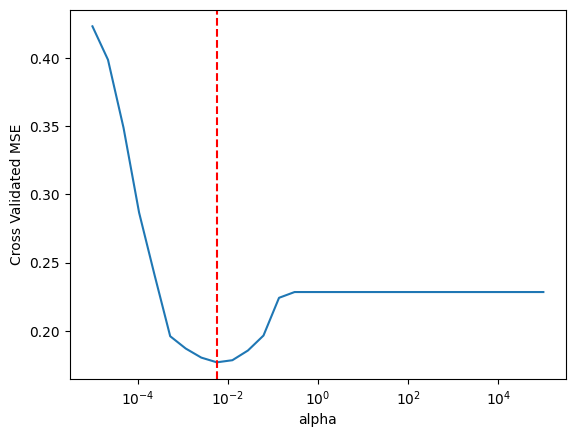

In [ ]:
#3.

from sklearn.linear_model import LassoCV

alphas = np.logspace(-5,5,30)
model = LassoCV(cv=20, alphas = alphas, random_state = 100, max_iter = 500000)
model = model.fit(X_matrix, y)

regularized_coefficients = model.coef_

#4.

alpha_star = model.alpha_

sns.lineplot( x=model.alphas_, y= np.mean(model.mse_path_,axis=1) )
plt.axvline(x=alpha_star, color='red', linestyle='--',
            linewidth=1.5)
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Cross Validated MSE")
print(f'Optimal cost hyperparameter: {alpha_star}')

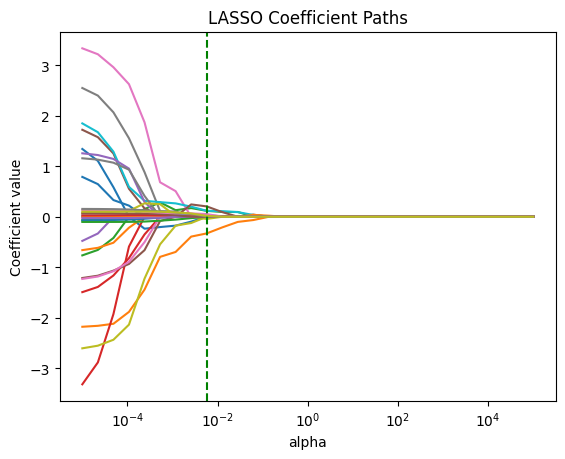

In [ ]:
#5.

from sklearn.linear_model import Lasso

alpha_grid = np.logspace(-5, 5, 30)
coefs = []
for alpha in alpha_grid:
    model = Lasso(alpha=alpha, max_iter=100000)
    model = model.fit(X_matrix,y)
    coefs.append(model.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alpha_grid, coefs[:, i], label=feature_names[i]) # Changed poly_names[i] to feature_names[i]
plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title("LASSO Coefficient Paths")
plt.axvline(x=alpha_star, color='green', linestyle='--')
plt.show()

In [ ]:
#6.
selected_features = [name for name, coef in zip(feature_names, model.coef_) if coef != 0]

print("Selected features:", selected_features)

prop_zero_coef = np.sum(model.coef_ == 0)/len(model.coef_)

print("Proportion set equal to zero:", prop_zero_coef)

regularized_coefficients = model.coef_

pd.DataFrame({'Linear regression':linear_coefficients, "Lasso": regularized_coefficients}, index = feature_names)

Selected features: ['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking']
Proportion set equal to zero: 0.5862068965517241


,Linear regression,Lasso
age,1.539156,-0.000000
ejection_fraction,-2.192494,-0.329656
serum_creatinine,-0.853588,0.116875
age^2,-3.678654,0.000000
age ejection_fraction,-0.600918,-0.000000
age serum_creatinine,1.841563,0.000000
ejection_fraction^2,3.430976,0.000000
ejection_fraction serum_creatinine,2.673394,0.000000
serum_creatinine^2,-2.647041,-0.000000
age^3,1.993135,0.117992


The features that were actually selected were ['ejection_fraction', 'serum_creatinine', 'age^3', 'ejection_fraction^3', 'ejection_fraction^2 serum_creatinine', 'serum_creatinine^3', 'anaemia', 'diabetes', 'high_blood_pressure', 'diabetes high_blood_pressure', 'diabetes smoking', 'high_blood_pressure smoking'], while the rest, or .59, were set to 0. None of the coefficients increased in size with LASSO, which makes sense as LASSO shrinks feature coefficients to make the model more accurate. Additionally, the signs for serum_creatinine, diabetes, high blood pressure, ejection_fraction^3,  ejection_fraction^2 serum_creatinine, and serum_creatinine^3 changed signs. These sign patterns make more sense than with the linear coefficient patterns, with the serum_creatinine, diabetes, and high blood pressure being negative coefficients and smoking set to 0, as opposed to their counterintitive positive coefficients before. This makes sense with the bias-variance trade-off because the linear model overfitts the data when it closely follows the training data with high variance and low bias, with many features with multicollinearity and assigning signs that do not make intuitive sense to minimize error, like with serum_creatinine, diabetes, and high blood pressure. However, with the LASSO, the best features are selected and others are reduced to 0, which reduces the variance of the model but makes it more generalizable and increases the bias in the bias-variance trade-off.

##4.

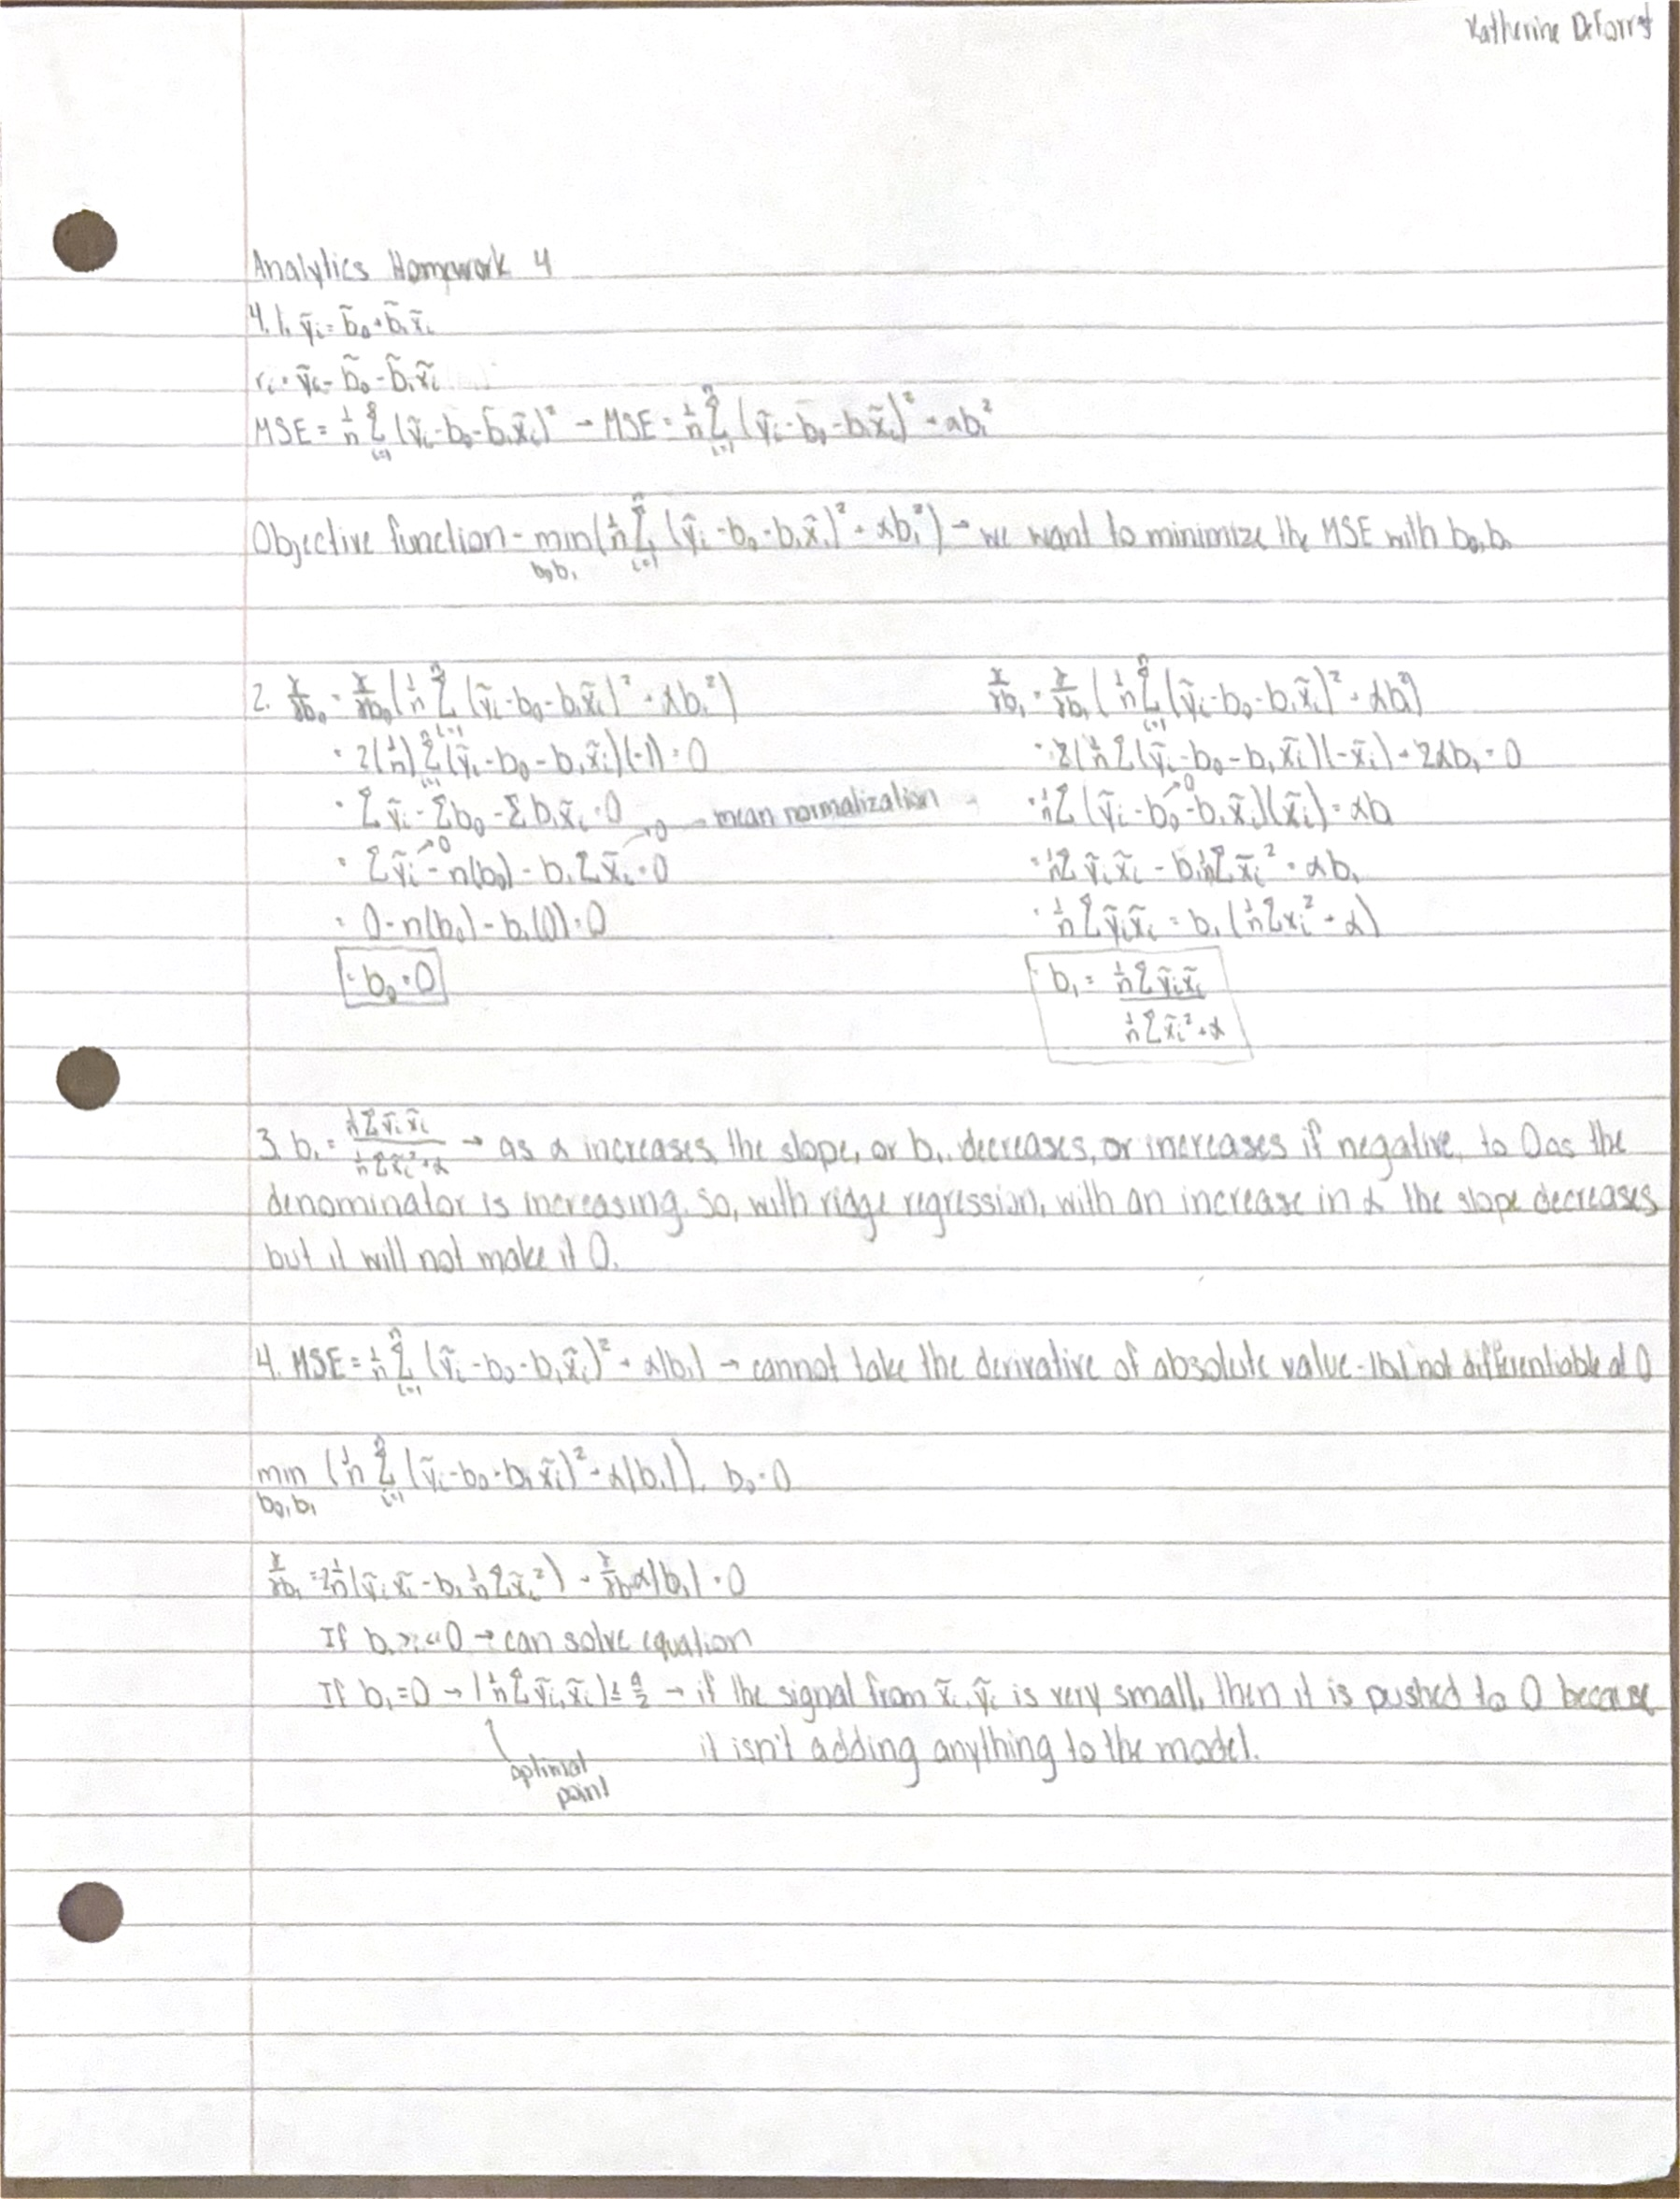